In [2]:
import os, json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [3]:
def read_result_file(file_path):
    with open(file_path, 'r') as f:
        results = f.readlines()

    result_dict = dict()
    k=0
    for l in results:
        l = l.strip()

        if (l.startswith('Test') and 'baseline accuracy: ' in l) or l.startswith('baseline accuracy: '):
            baseline_acc = 1 - float(l[-6:])
            result_dict['baseline_acc'] = baseline_acc
        elif l.startswith('AutoFL-Confidence accuracy: '):
            result_dict['autofl_confidence_acc'] = float(l[-6:])
        elif l.startswith('AutoFL-Confidence roc-auc: '):
            result_dict['autofl_confidence_auc'] = float(l[-6:])
        elif l=='S':
            embedding = 'S'
            result_dict[embedding] = dict()
        elif l=='F':
            embedding = 'F'
            result_dict[embedding] = {}
        elif l=='FA':
            embedding = 'FA'
            result_dict[embedding] = {}
        elif l.startswith('k='):
            k=int(l[2:])
            result_dict[embedding][k] = {}
            # result_dict['baseline_acc'][k] = {'acc': baseline_acc}
        elif l.startswith('Best_mean_accuracy:') or l.startswith('Best accuracy: '):
            result_dict[embedding][k]['acc'] = float(l.split()[-1])
        elif l.startswith('Best mean_roc_auc:') or l.startswith('Best roc_auc'):
            result_dict[embedding][k]['roc_auc'] = float(l.split()[-1])
        elif l.startswith('Best mean_precision:') or l.startswith('Best precision'):
            result_dict[embedding][k]['precision'] = float(l.split()[-1])
        elif l.startswith('Best mean_recall:') or l.startswith('Best recall'):
            result_dict[embedding][k]['recall'] = float(l.split()[-1])
        elif l.startswith('Best mean_npv:') or l.startswith('Best npv'):
            result_dict[embedding][k]['npv'] = float(l.split()[-1])
        elif l.startswith('Best mean_specificity:') or l.startswith('Best specificity'):
            result_dict[embedding][k]['spec'] = float(l.split()[-1])
    print(result_dict)
    return result_dict

In [4]:

def draw_graph(data, title, y_data = 'acc'):
    colors = ['b', 'g', 'r', 'c', 'm', 'y']
    labels = list(data.keys())
    x = list(data[labels[3]].keys())

    if y_data == 'acc':
        baseline_acc = data['baseline_acc']
        autofl_confidence = data['autofl_confidence_acc']
        plt.plot(x, [baseline_acc] * len(x), linestyle='-', color = colors[-2], label='baseline acc.')
        plt.plot(x, [autofl_confidence] * len(x), linestyle='-', color = colors[-1], label='autofl_confidence acc.')
    elif y_data == 'roc_auc':
        autofl_confidence_auc = data['autofl_confidence_auc']
        plt.plot(x, [autofl_confidence_auc] * len(x), linestyle='-', color = colors[-1], label='autofl_confidence auc.')

    labels.remove('baseline_acc')
    labels.remove('autofl_confidence_acc')
    labels.remove('autofl_confidence_auc')
    for i, label in enumerate(labels):
        y = []
        for k in x:
            y.append(data[label][k][y_data])
        plt.plot(x, y, linestyle='-', color=colors[i], label=label)
    
    plt.title(title)
    plt.xlabel('k')
    plt.ylabel(y_data)

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    

{'autofl_confidence_acc': 0.7101, 'autofl_confidence_auc': 0.76, 'baseline_acc': 0.6667000000000001, 'S': {1: {'acc': 0.6667, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 2: {'acc': 0.6667, 'roc_auc': 0.5378, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 3: {'acc': 0.6667, 'roc_auc': 0.4132, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 4: {'acc': 0.6667, 'roc_auc': 0.3573, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 5: {'acc': 0.6696, 'roc_auc': 0.3999, 'precision': 0.1333, 'recall': 0.016, 'npv': 0.6694, 'spec': 0.9955}, 6: {'acc': 0.6667, 'roc_auc': 0.3926, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 7: {'acc': 0.6667, 'roc_auc': 0.3811, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 8: {'acc': 0.6667, 'roc_auc': 0.45, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 9: {'acc': 0.6667, 'roc_auc': 0.3911, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spe

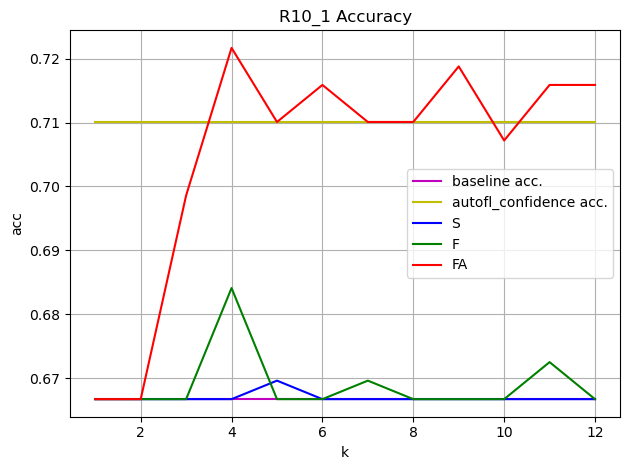

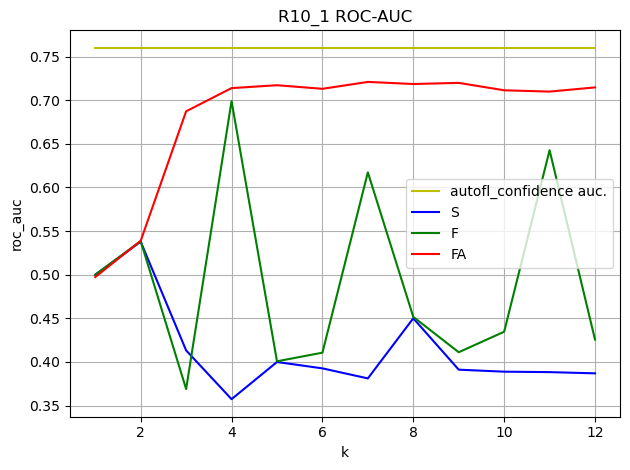

In [5]:
model = 'llama3'
repetition = 10
num_files = 1

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} ROC-AUC', 'roc_auc')

{'autofl_confidence_acc': 0.7072, 'autofl_confidence_auc': 0.7347, 'baseline_acc': 0.6579999999999999, 'S': {1: {'acc': 0.658, 'roc_auc': 0.5081, 'precision': 0.0, 'recall': 0.0, 'npv': 0.658, 'spec': 1.0}, 2: {'acc': 0.658, 'roc_auc': 0.5299, 'precision': 0.0, 'recall': 0.0, 'npv': 0.658, 'spec': 1.0}, 3: {'acc': 0.658, 'roc_auc': 0.363, 'precision': 0.0, 'recall': 0.0, 'npv': 0.658, 'spec': 1.0}, 4: {'acc': 0.658, 'roc_auc': 0.3554, 'precision': 0.0, 'recall': 0.0, 'npv': 0.658, 'spec': 1.0}, 5: {'acc': 0.658, 'roc_auc': 0.3793, 'precision': 0.0, 'recall': 0.0, 'npv': 0.658, 'spec': 1.0}, 6: {'acc': 0.658, 'roc_auc': 0.3895, 'precision': 0.0, 'recall': 0.0, 'npv': 0.658, 'spec': 1.0}, 7: {'acc': 0.658, 'roc_auc': 0.3736, 'precision': 0.0, 'recall': 0.0, 'npv': 0.658, 'spec': 1.0}, 8: {'acc': 0.658, 'roc_auc': 0.3858, 'precision': 0.0, 'recall': 0.0, 'npv': 0.658, 'spec': 1.0}, 9: {'acc': 0.658, 'roc_auc': 0.3931, 'precision': 0.0, 'recall': 0.0, 'npv': 0.658, 'spec': 1.0}, 10: {'acc'

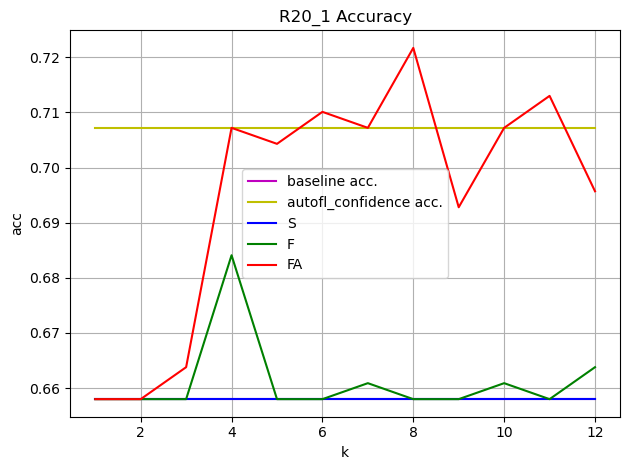

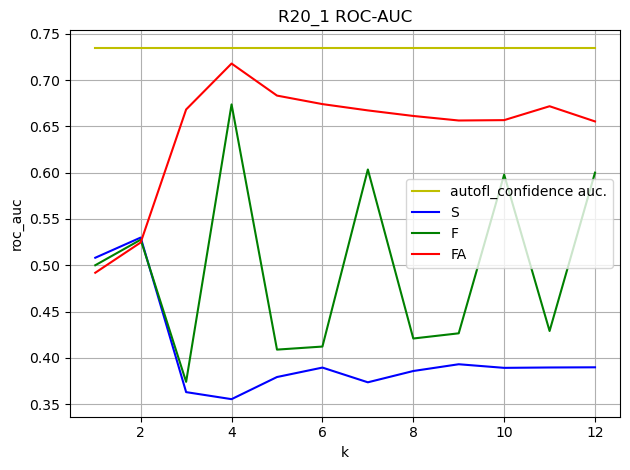

In [6]:
model = 'llama3'
repetition = 20
num_files = 1

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} ROC-AUC', 'roc_auc')

{'autofl_confidence_acc': 0.7217, 'autofl_confidence_auc': 0.7383, 'baseline_acc': 0.6786, 'S': {1: {'acc': 0.6786, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6786, 'spec': 1.0}, 2: {'acc': 0.6786, 'roc_auc': 0.5469, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6786, 'spec': 1.0}, 3: {'acc': 0.6786, 'roc_auc': 0.3764, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6786, 'spec': 1.0}, 4: {'acc': 0.6786, 'roc_auc': 0.3854, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6786, 'spec': 1.0}, 5: {'acc': 0.6786, 'roc_auc': 0.4031, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6786, 'spec': 1.0}, 6: {'acc': 0.6786, 'roc_auc': 0.4036, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6786, 'spec': 1.0}, 7: {'acc': 0.6786, 'roc_auc': 0.3966, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6786, 'spec': 1.0}, 8: {'acc': 0.6786, 'roc_auc': 0.4041, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6786, 'spec': 1.0}, 9: {'acc': 0.6786, 'roc_auc': 0.4058, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6786, 'spec': 1.0}, 10: {'

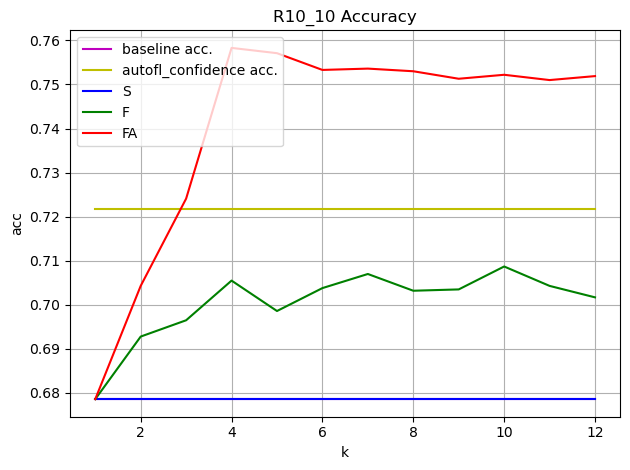

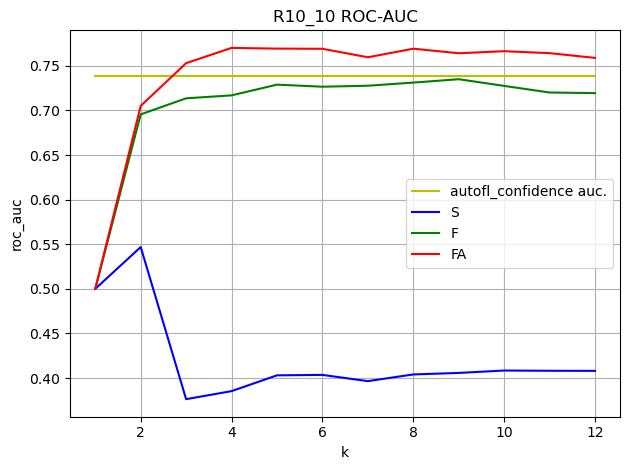

In [7]:
model = 'llama3'
repetition = 10
num_files = 10

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} ROC-AUC', 'roc_auc')

{'autofl_confidence_acc': 0.6841, 'autofl_confidence_auc': 0.7366, 'baseline_acc': 0.6531, 'S': {1: {'acc': 0.6531, 'roc_auc': 0.5029, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6531, 'spec': 1.0}, 2: {'acc': 0.6531, 'roc_auc': 0.5436, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6531, 'spec': 1.0}, 3: {'acc': 0.6531, 'roc_auc': 0.3683, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6531, 'spec': 1.0}, 4: {'acc': 0.6531, 'roc_auc': 0.3507, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6531, 'spec': 1.0}, 5: {'acc': 0.6531, 'roc_auc': 0.3773, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6531, 'spec': 1.0}, 6: {'acc': 0.6531, 'roc_auc': 0.385, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6531, 'spec': 1.0}, 7: {'acc': 0.6531, 'roc_auc': 0.3775, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6531, 'spec': 1.0}, 8: {'acc': 0.6531, 'roc_auc': 0.3831, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6531, 'spec': 1.0}, 9: {'acc': 0.6531, 'roc_auc': 0.3865, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6531, 'spec': 1.0}, 10: 

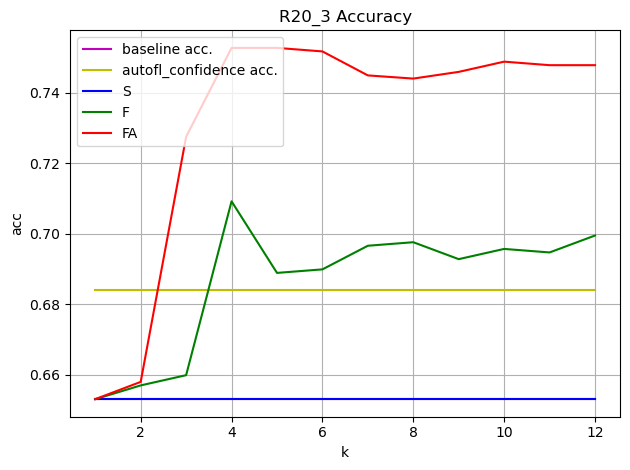

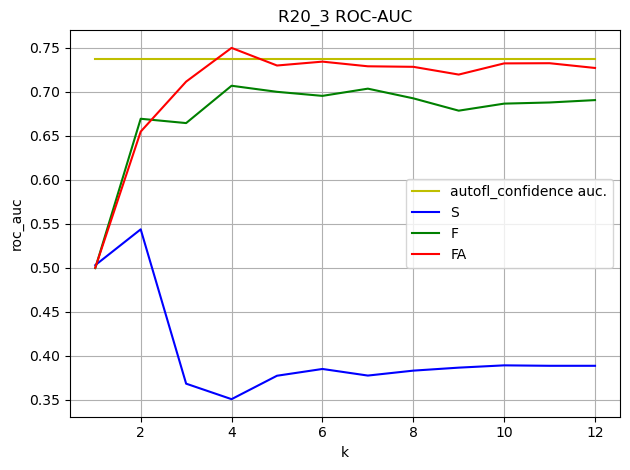

In [8]:
model = 'llama3'
repetition = 20
num_files = 3

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} ROC-AUC', 'roc_auc')

{'autofl_confidence_acc': 0.7101, 'autofl_confidence_auc': 0.7434, 'baseline_acc': 0.6477999999999999, 'S': {1: {'acc': 0.6478, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6478, 'spec': 1.0}, 2: {'acc': 0.6478, 'roc_auc': 0.5429, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6478, 'spec': 1.0}, 3: {'acc': 0.6478, 'roc_auc': 0.3716, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6478, 'spec': 1.0}, 4: {'acc': 0.653, 'roc_auc': 0.6571, 'precision': 0.4655, 'recall': 0.0591, 'npv': 0.6564, 'spec': 0.9754}, 5: {'acc': 0.6478, 'roc_auc': 0.3773, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6478, 'spec': 1.0}, 6: {'acc': 0.6542, 'roc_auc': 0.6337, 'precision': 0.4012, 'recall': 0.0727, 'npv': 0.6586, 'spec': 0.9705}, 7: {'acc': 0.6507, 'roc_auc': 0.6407, 'precision': 0.3987, 'recall': 0.0569, 'npv': 0.6552, 'spec': 0.9726}, 8: {'acc': 0.6493, 'roc_auc': 0.6374, 'precision': 0.4294, 'recall': 0.0385, 'npv': 0.6526, 'spec': 0.9812}, 9: {'acc': 0.6478, 'roc_auc': 0.3859, 'precision': 0.0, 're

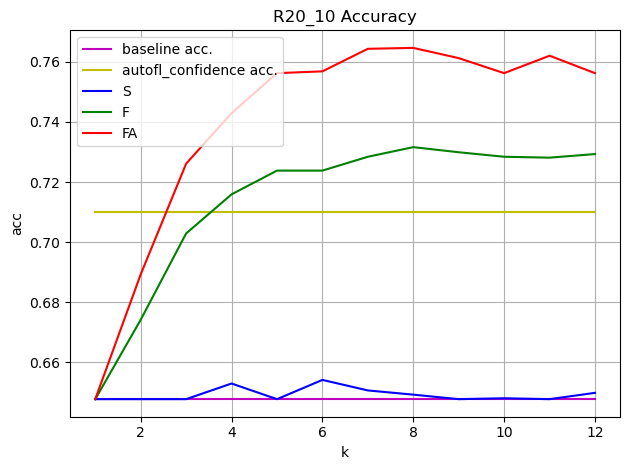

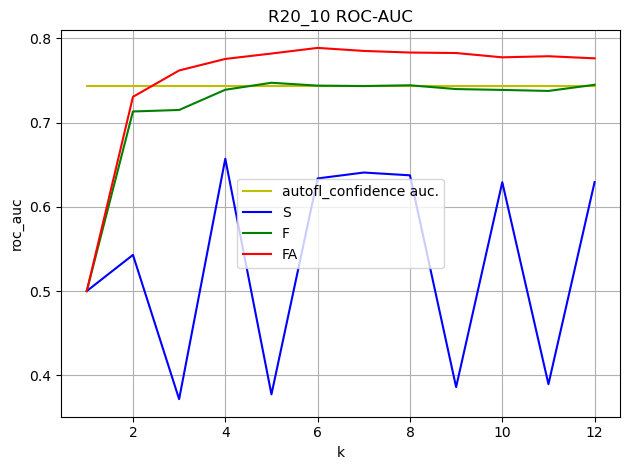

In [9]:
model = 'llama3'
repetition = 20
num_files = 10

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} ROC-AUC', 'roc_auc')

{'autofl_confidence_acc': 0.7101, 'autofl_confidence_auc': 0.76, 'baseline_acc': 0.6667000000000001, 'S': {1: {'acc': 0.6667, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 2: {'acc': 0.6667, 'roc_auc': 0.5378, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 3: {'acc': 0.6667, 'roc_auc': 0.4132, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 4: {'acc': 0.6667, 'roc_auc': 0.3573, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 5: {'acc': 0.6696, 'roc_auc': 0.3999, 'precision': 0.1333, 'recall': 0.016, 'npv': 0.6694, 'spec': 0.9955}, 6: {'acc': 0.6667, 'roc_auc': 0.3926, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 7: {'acc': 0.6667, 'roc_auc': 0.3811, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 8: {'acc': 0.6667, 'roc_auc': 0.45, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 9: {'acc': 0.6667, 'roc_auc': 0.3911, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spe

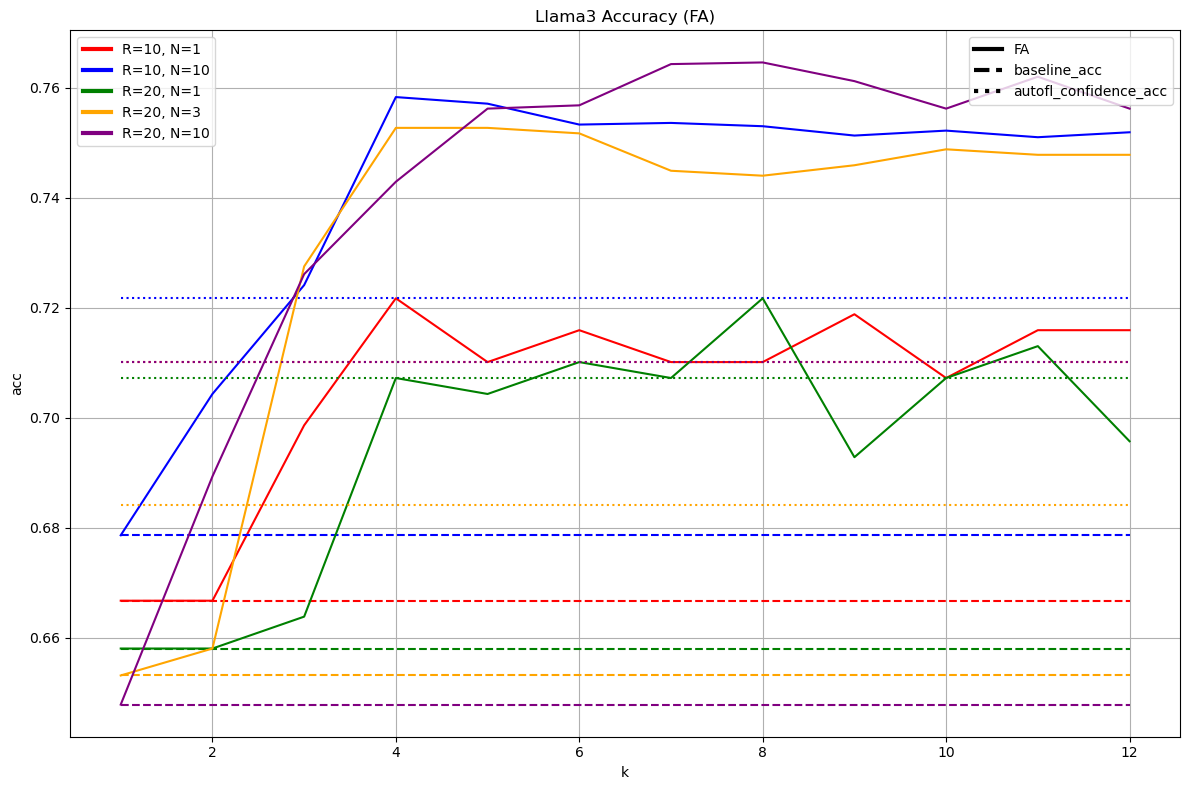

In [10]:

def draw_combination_graph(title, y_data = 'acc'):
    # base_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:yellow']
    base_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    line_styles = {'FA': '-', 'baseline_acc': '--', 'autofl_confidence_acc': ':'}

    labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10', (20, 1): 'R=20, N=1', (20, 3): 'R=20, N=3', (20, 10): 'R=20, N=10'}
    # labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10'}
    x = range(1, 13)

    plt.figure(figsize=(12, 8))

    for i, ((repetition, num_files), color) in enumerate(zip(labels.keys(), base_colors)):
        result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

        result_dict = read_result_file(result_file)
        
        for key in ['FA']:
            y = []
            for k in x:
                y.append(result_dict[key][k][y_data])
            
            plt.plot(
                x,
                y,
                color = color,
                linestyle=line_styles[key],
                label = f"{labels[(repetition, num_files)]} - {key}"
            )
        
        # Baseline acc
        y = []
        for k in x:
            y.append(result_dict['baseline_acc'])
        
        plt.plot(
            x,
            y,
            color = color,
            linestyle=line_styles['baseline_acc'],
            # label = f"{labels[(repetition, num_files)]} - {key}"
        )

        # AutoFL-Confidence acc
        y = []
        for k in x:
            y.append(result_dict['autofl_confidence_acc'])
        
        plt.plot(
            x,
            y,
            color = color,
            linestyle=line_styles['autofl_confidence_acc'],
            # label = f"{labels[(repetition, num_files)]} - {key}"
        )
    
    
    plt.title(title)
    plt.xlabel('k')
    plt.ylabel(y_data)

    color_legend = [
        Line2D([0], [0], color=base_colors[i], lw=3, label=labels[((rep, num))]) 
        for i, (rep,num) in enumerate(labels.keys())
    ]

    first_legend = plt.legend(handles=color_legend, loc='upper left')
    plt.gca().add_artist(first_legend)

    style_legend = [
        Line2D([0], [0], color = 'black', linestyle=line_styles[key], lw=3, label=key) 
        for key in ['FA', 'baseline_acc', 'autofl_confidence_acc']
    ]
    plt.legend(handles = style_legend, loc='upper right')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

draw_combination_graph("Llama3 Accuracy (FA)", 'acc')
    

{'autofl_confidence_acc': 0.7101, 'autofl_confidence_auc': 0.76, 'baseline_acc': 0.6667000000000001, 'S': {1: {'acc': 0.6667, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 2: {'acc': 0.6667, 'roc_auc': 0.5378, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 3: {'acc': 0.6667, 'roc_auc': 0.4132, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 4: {'acc': 0.6667, 'roc_auc': 0.3573, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 5: {'acc': 0.6696, 'roc_auc': 0.3999, 'precision': 0.1333, 'recall': 0.016, 'npv': 0.6694, 'spec': 0.9955}, 6: {'acc': 0.6667, 'roc_auc': 0.3926, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 7: {'acc': 0.6667, 'roc_auc': 0.3811, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 8: {'acc': 0.6667, 'roc_auc': 0.45, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 9: {'acc': 0.6667, 'roc_auc': 0.3911, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spe

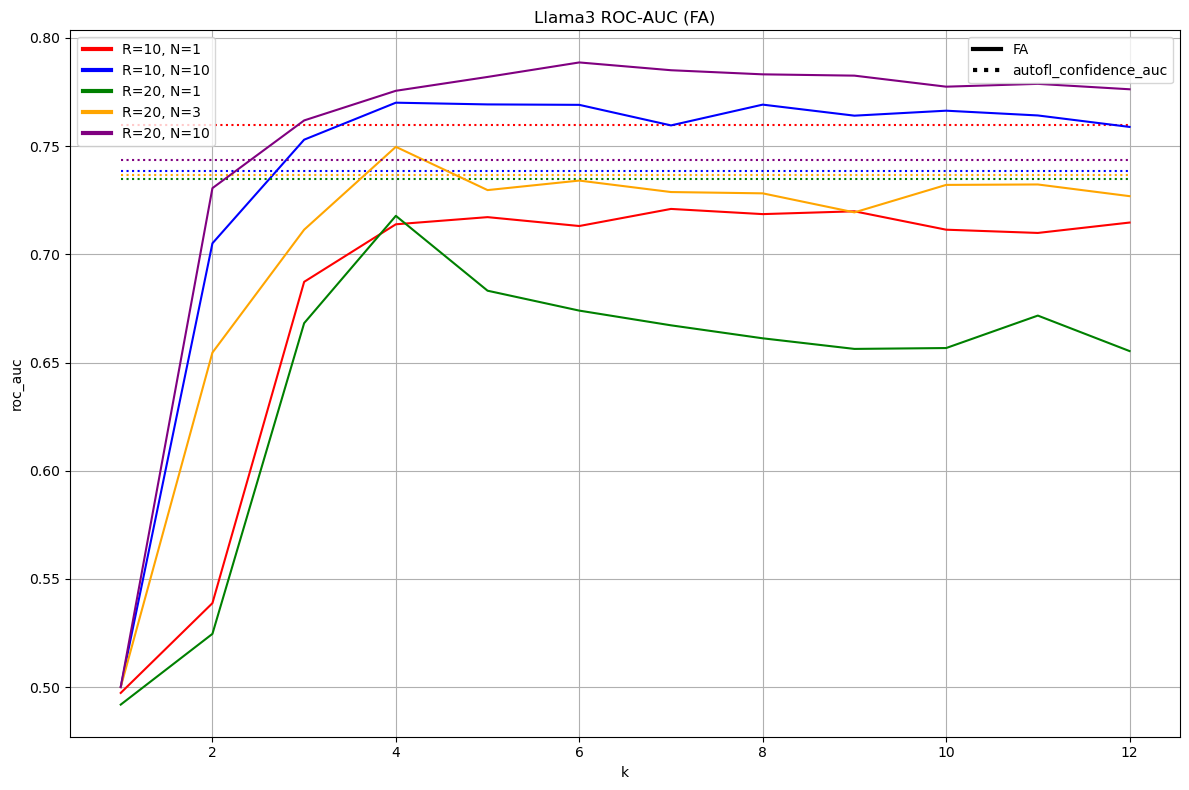

In [11]:

def draw_combination_graph(title, y_data = 'roc_auc'):
    # base_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:yellow']
    base_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    line_styles = {'FA': '-', 'autofl_confidence_auc': ':'}

    labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10', (20, 1): 'R=20, N=1', (20, 3): 'R=20, N=3', (20, 10): 'R=20, N=10'}
    # labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10'}
    x = range(1, 13)

    plt.figure(figsize=(12, 8))

    for i, ((repetition, num_files), color) in enumerate(zip(labels.keys(), base_colors)):
        result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

        result_dict = read_result_file(result_file)
        print(result_dict)
        
        for key in ['FA']:
            y = []
            for k in x:
                y.append(result_dict[key][k][y_data])
            
            plt.plot(
                x,
                y,
                color = color,
                linestyle=line_styles[key],
                label = f"{labels[(repetition, num_files)]} - {key}"
            )
        

        # AutoFL-Confidence acc
        y = []
        for k in x:
            y.append(result_dict['autofl_confidence_auc'])
        
        plt.plot(
            x,
            y,
            color = color,
            linestyle=line_styles['autofl_confidence_auc'],
            # label = f"{labels[(repetition, num_files)]} - {key}"
        )
    
    
    plt.title(title)
    plt.xlabel('k')
    plt.ylabel(y_data)

    color_legend = [
        Line2D([0], [0], color=base_colors[i], lw=3, label=labels[((rep, num))]) 
        for i, (rep,num) in enumerate(labels.keys())
    ]

    first_legend = plt.legend(handles=color_legend, loc='upper left')
    plt.gca().add_artist(first_legend)

    style_legend = [
        Line2D([0], [0], color = 'black', linestyle=line_styles[key], lw=3, label=key) 
        for key in ['FA', 'autofl_confidence_auc']
    ]
    plt.legend(handles = style_legend, loc='upper right')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

draw_combination_graph("Llama3 ROC-AUC (FA)", 'roc_auc')
    

{'autofl_confidence_acc': 0.7101, 'autofl_confidence_auc': 0.76, 'baseline_acc': 0.6667000000000001, 'S': {1: {'acc': 0.6667, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 2: {'acc': 0.6667, 'roc_auc': 0.5378, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 3: {'acc': 0.6667, 'roc_auc': 0.4132, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 4: {'acc': 0.6667, 'roc_auc': 0.3573, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 5: {'acc': 0.6696, 'roc_auc': 0.3999, 'precision': 0.1333, 'recall': 0.016, 'npv': 0.6694, 'spec': 0.9955}, 6: {'acc': 0.6667, 'roc_auc': 0.3926, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 7: {'acc': 0.6667, 'roc_auc': 0.3811, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 8: {'acc': 0.6667, 'roc_auc': 0.45, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spec': 1.0}, 9: {'acc': 0.6667, 'roc_auc': 0.3911, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6667, 'spe

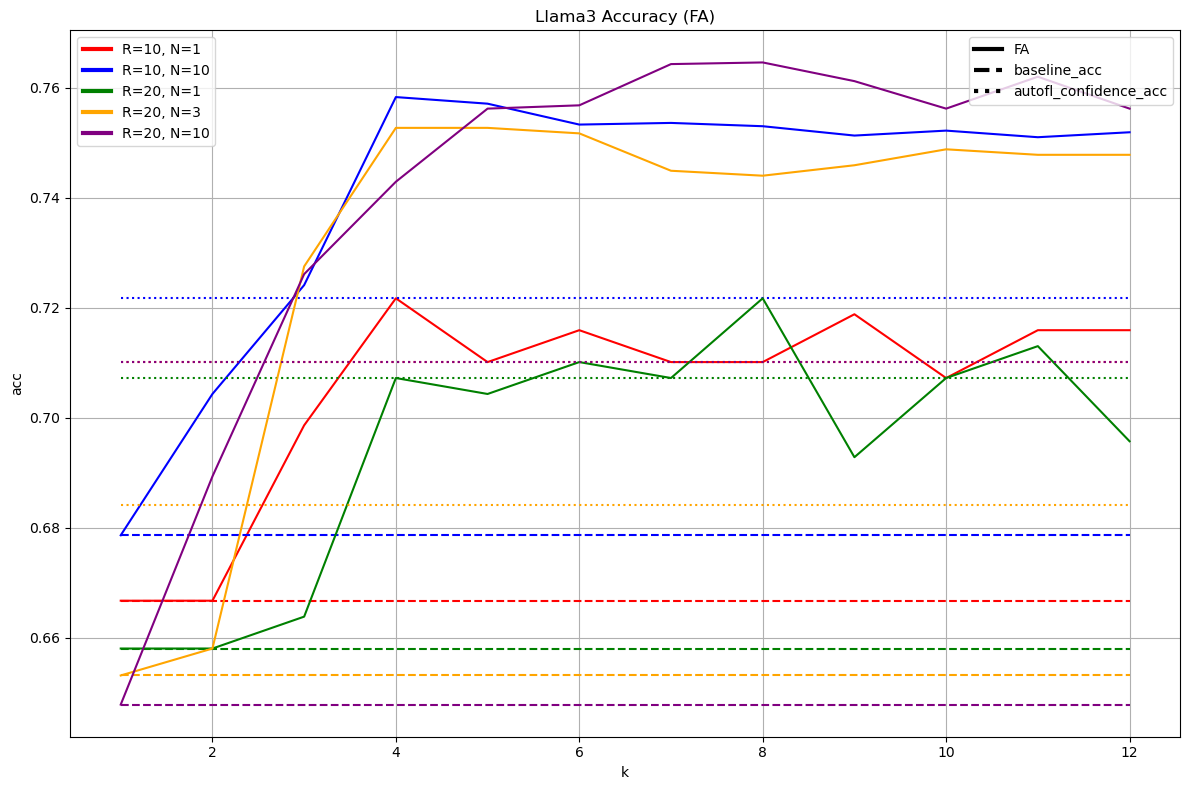

In [12]:

def draw_combination_graph(title, y_data = 'acc'):
    # base_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:yellow']
    base_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    line_styles = {'FA': '-', 'baseline_acc': '--', 'autofl_confidence_acc': ':'}

    labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10', (20, 1): 'R=20, N=1', (20, 3): 'R=20, N=3', (20, 10): 'R=20, N=10'}
    # labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10'}
    x = range(1, 13)

    plt.figure(figsize=(12, 8))

    for i, ((repetition, num_files), color) in enumerate(zip(labels.keys(), base_colors)):
        result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

        result_dict = read_result_file(result_file)
        
        for key in ['FA']:
            y = []
            for k in x:
                y.append(result_dict[key][k][y_data])
            
            plt.plot(
                x,
                y,
                color = color,
                linestyle=line_styles[key],
                label = f"{labels[(repetition, num_files)]} - {key}"
            )
        
        # Baseline acc
        y = []
        for k in x:
            y.append(result_dict['baseline_acc'])
        
        plt.plot(
            x,
            y,
            color = color,
            linestyle=line_styles['baseline_acc'],
            # label = f"{labels[(repetition, num_files)]} - {key}"
        )

        # AutoFL-Confidence acc
        y = []
        for k in x:
            y.append(result_dict['autofl_confidence_acc'])
        
        plt.plot(
            x,
            y,
            color = color,
            linestyle=line_styles['autofl_confidence_acc'],
            # label = f"{labels[(repetition, num_files)]} - {key}"
        )
    
    
    plt.title(title)
    plt.xlabel('k')
    plt.ylabel(y_data)

    color_legend = [
        Line2D([0], [0], color=base_colors[i], lw=3, label=labels[((rep, num))]) 
        for i, (rep,num) in enumerate(labels.keys())
    ]

    first_legend = plt.legend(handles=color_legend, loc='upper left')
    plt.gca().add_artist(first_legend)

    style_legend = [
        Line2D([0], [0], color = 'black', linestyle=line_styles[key], lw=3, label=key) 
        for key in ['FA', 'baseline_acc', 'autofl_confidence_acc']
    ]
    plt.legend(handles = style_legend, loc='upper right')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

draw_combination_graph("Llama3 Accuracy (FA)", 'acc')
    

{'autofl_confidence_acc': 0.6536, 'autofl_confidence_auc': 0.6373, 'baseline_acc': 0.6783, 'FA': {1: {'acc': 0.6783, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6783}, 2: {'acc': 0.6928, 'roc_auc': 0.6223, 'precision': 1.0, 'recall': 1.0, 'npv': 0.6882}, 3: {'acc': 0.6812, 'roc_auc': 0.6684, 'precision': 0.5066, 'recall': 0.5066, 'npv': 0.7305}, 4: {'acc': 0.713, 'roc_auc': 0.6776, 'precision': 0.5984, 'recall': 0.5984, 'npv': 0.7377}, 5: {'acc': 0.7609, 'roc_auc': 0.7287, 'precision': 0.6966, 'recall': 0.6966, 'npv': 0.778}, 6: {'acc': 0.7725, 'roc_auc': 0.7406, 'precision': 0.6901, 'recall': 0.6901, 'npv': 0.7996}, 7: {'acc': 0.7594, 'roc_auc': 0.7282, 'precision': 0.6867, 'recall': 0.6867, 'npv': 0.7796}, 8: {'acc': 0.7536, 'roc_auc': 0.717, 'precision': 0.6733, 'recall': 0.6733, 'npv': 0.7759}, 9: {'acc': 0.7507, 'roc_auc': 0.727, 'precision': 0.6736, 'recall': 0.6736, 'npv': 0.7711}, 10: {'acc': 0.7522, 'roc_auc': 0.7307, 'precision': 0.6861, 'recall': 0.6861, 'npv':

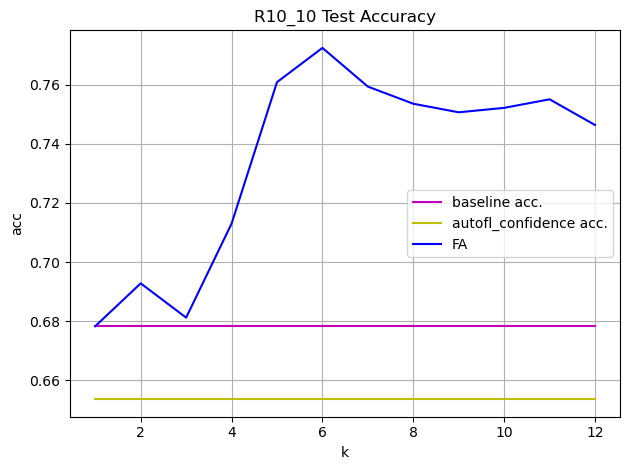

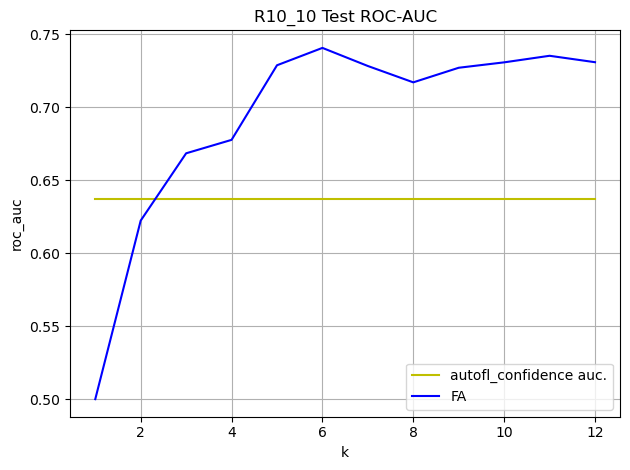

In [13]:
model = 'llama3'
repetition = 10
num_files = 10

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files_wo_cv.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Test Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} Test ROC-AUC', 'roc_auc')

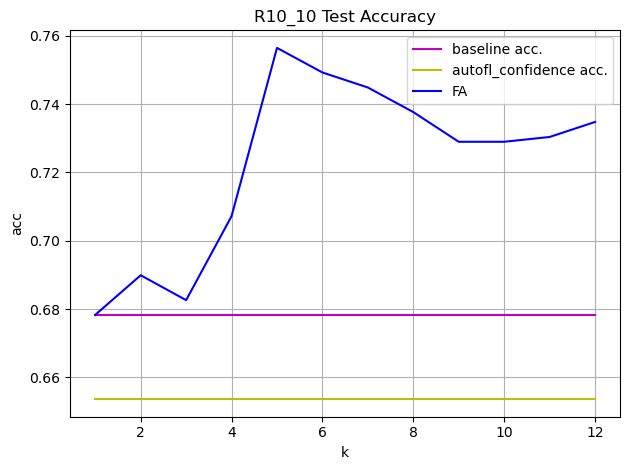

In [14]:
test_result_dict = {'autofl_confidence_acc': 0.6536, 'autofl_confidence_auc': 0.6373, 'baseline_acc': 0.6783, 'FA': {1: {'acc': 0.6783}, 2: {'acc': 0.6899}, 3: {'acc': 0.6826}, 4: {'acc': 0.7072}, 5: {'acc': 0.7565}, 6: {'acc': 0.7493}, 7: {'acc': 0.7449}, 8: {'acc': 0.7377}, 9: {'acc': 0.7290}, 10: {'acc': 0.7290}, 11: {'acc': 0.7304}, 12: {'acc': 0.7348}}}

model = 'llama3'
repetition = 10
num_files = 10

draw_graph(test_result_dict, f'R{repetition}_{num_files} Test Accuracy', 'acc')